In [290]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [291]:
# ==========================
# IMPORT LIBRARIES
# ==========================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [292]:
# ==========================
# LOAD DATA
# ==========================

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [293]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [294]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


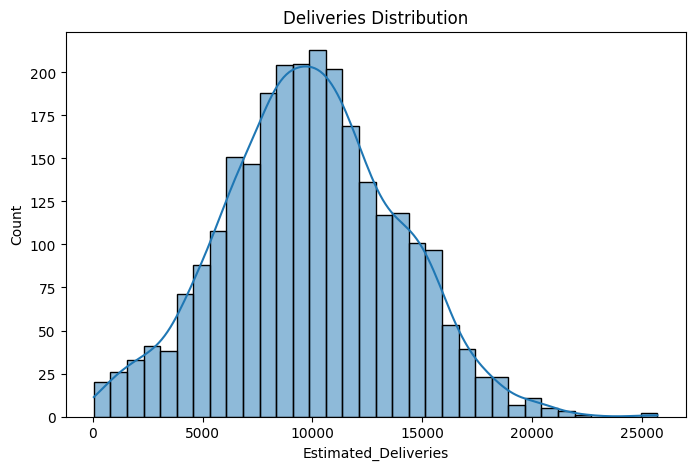

In [295]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], kde=True)
plt.title("Deliveries Distribution")
plt.show()

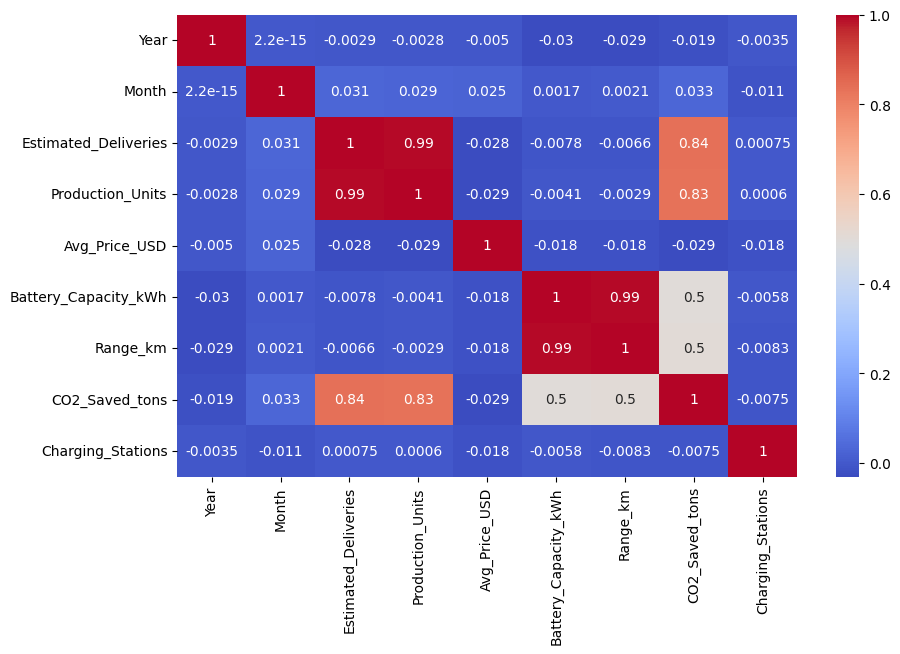

In [296]:
plt.figure(figsize=(10,6))

numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

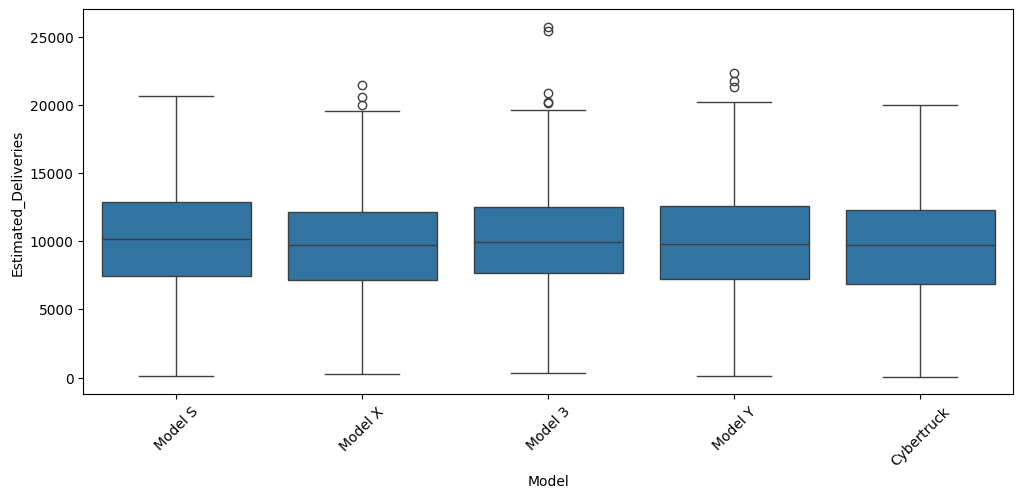

In [297]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)
plt.show()

In [298]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [299]:
print(df.head())
print(type(df))

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [300]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())
print(df.shape)

Duplicates before: 0
Duplicates after: 0
(2640, 12)


In [301]:
print(df[['Year','Month']].head())
print(df[['Year','Month']].dtypes)

   Year  Month
0  2023      5
1  2015      2
2  2019      1
3  2021      2
4  2016     12
Year     int64
Month    int64
dtype: object


In [302]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01',
    errors='coerce'
)

print(df['Date'].head())

0   2023-05-01
1   2015-02-01
2   2019-01-01
3   2021-02-01
4   2016-12-01
Name: Date, dtype: datetime64[ns]


In [303]:
print(type(df))
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date']


In [304]:
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df["Rolling_STD_3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .std()
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Rolling_Mean_3,Rolling_STD_3
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,NaN,NaN
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,NaN,NaN
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,9951.333333,7051.820356
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,6254.333333,2321.647978
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,9113.333333,2972.397069


In [305]:
print(df["Date"].dtype)

datetime64[ns]


In [306]:
# Ensure Month is numeric
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")

# Quarter feature
df["Quarter"] = df["Date"].dt.quarter

# Cyclical month features
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)

df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

print(df[["Month", "Quarter", "Month_sin", "Month_cos"]].head())

   Month  Quarter     Month_sin  Month_cos
0      5        2  5.000000e-01  -0.866025
1      2        1  8.660254e-01   0.500000
2      1        1  5.000000e-01   0.866025
3      2        1  8.660254e-01   0.500000
4     12        4 -2.449294e-16   1.000000


In [307]:
print(type(df))
print(df.shape)

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
(2640, 18)
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
Rolling_Mean_3          2
Rolling_STD_3           2
Quarter                 0
Month_sin               0
Month_cos               0
dtype: int64


In [308]:
df = df.dropna()

print(df.shape)

(2638, 18)


In [309]:
# Target variable
y = df["Estimated_Deliveries"]

# Features
X = df.drop(
    ["Estimated_Deliveries", "Date"],
    axis=1,
    errors="ignore"
)

print(X.shape)
print(y.shape)

(2638, 16)
(2638,)


In [310]:
print(type(X))

<class 'pandas.core.frame.DataFrame'>


In [311]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)

Numerical Features: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Rolling_Mean_3', 'Rolling_STD_3', 'Month_sin', 'Month_cos']
Categorical Features: ['Region', 'Model', 'Source_Type']


In [312]:
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(cat_features)

['Region', 'Model', 'Source_Type']


In [313]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", num_features)
print("Categorical:", cat_features)

Numerical: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Rolling_Mean_3', 'Rolling_STD_3', 'Month_sin', 'Month_cos']
Categorical: ['Region', 'Model', 'Source_Type']


In [314]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_features
        )
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [315]:
# Target variable
y = df["Estimated_Deliveries"]

# Features
X = df.drop(columns=["Estimated_Deliveries"], errors="ignore")

# Train-Test Split (80-20)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2110, 17)
X_test shape: (528, 17)
y_train shape: (2110,)
y_test shape: (528,)


In [316]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Rolling_Mean_3', 'Rolling_STD_3', 'Quarter', 'Month_sin', 'Month_cos']


In [317]:
categorical_cols = ["Region", "Model", "Source_Type"]

for col in categorical_cols:
    df[col] = df[col].astype(str)

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols
)

print(df_encoded.shape)

(2638, 27)


In [318]:
# Target
y = df_encoded["Estimated_Deliveries"]

# Features
X = df_encoded.drop(
    columns=["Estimated_Deliveries"],
    errors="ignore"
)

# Remove Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

print(X.shape)
print(y.shape)

(2638, 25)
(2638,)


In [319]:
print(X.dtypes[X.dtypes == "object"])

Series([], dtype: object)


In [320]:
# Convert all categorical columns to dummy variables
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.dtypes.unique())

(2638, 25)
[dtype('int64') dtype('float64') dtype('int32') dtype('bool')]


In [321]:
print(type(df))
print(type(df_encoded))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [322]:
print(df_encoded.dtypes)

Year                                         int64
Month                                        int64
Estimated_Deliveries                         int64
Production_Units                             int64
Avg_Price_USD                              float64
Battery_Capacity_kWh                         int64
Range_km                                     int64
CO2_Saved_tons                             float64
Charging_Stations                            int64
Date                                datetime64[ns]
Rolling_Mean_3                             float64
Rolling_STD_3                              float64
Quarter                                      int32
Month_sin                                  float64
Month_cos                                  float64
Region_Asia                                   bool
Region_Europe                                 bool
Region_Middle East                            bool
Region_North America                          bool
Model_Cybertruck               

In [323]:
# Convert everything except target to numeric features
df_encoded = pd.get_dummies(df, drop_first=True)

# Remove Date column if present
if 'Date' in df_encoded.columns:
    df_encoded = df_encoded.drop('Date', axis=1)

# Target
y = df_encoded['Estimated_Deliveries']

# Features
X = df_encoded.drop('Estimated_Deliveries', axis=1)

print(X.dtypes.value_counts())
print(X.shape)

bool       9
int64      6
float64    6
int32      1
Name: count, dtype: int64
(2638, 22)


In [324]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [325]:
print(X_train.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [326]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [327]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

preds = lr.predict(X_test_scaled)

print("Model trained successfully")

Model trained successfully


In [328]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2  :", r2_score(y_test, preds))

MAE : 312.622836664901
RMSE: 379.94100416217634
R2  : 0.9905903511139506


In [329]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_preds = ridge.predict(X_test_scaled)

print("Ridge R2:", r2_score(y_test, ridge_preds))

Ridge R2: 0.9905806466993617


In [330]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

lasso_preds = lasso.predict(X_test_scaled)

print("Lasso R2:", r2_score(y_test, lasso_preds))

Lasso R2: 0.990593754809744


In [331]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

scores = cross_val_score(
    ridge,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", scores)
print("Mean CV Score:", scores.mean())

CV Scores: [0.99063719 0.99027736 0.98928203 0.99031141 0.99063034]
Mean CV Score: 0.9902276657916378


In [332]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train_scaled, y_train)

print("Best Alpha:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Alpha: {'alpha': 1}
Best Score: 0.9901168458513727


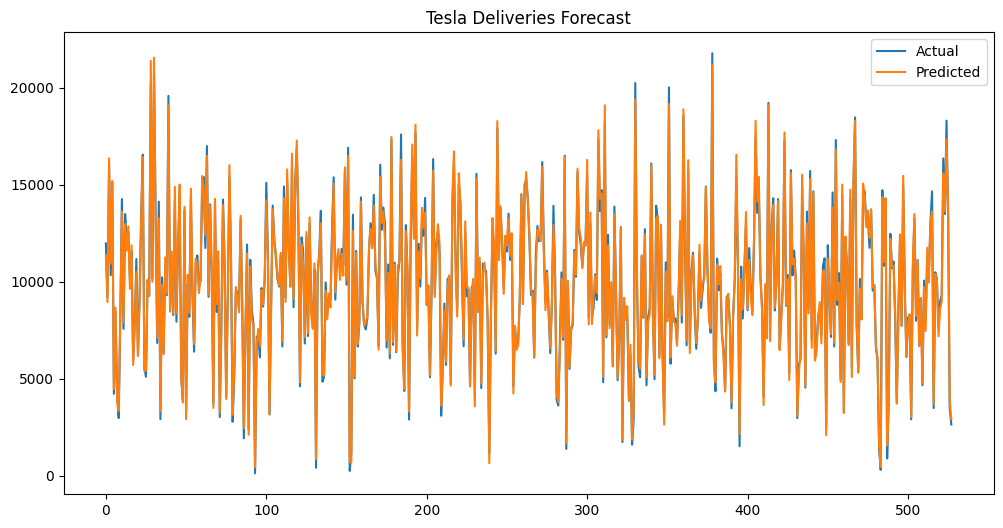

In [333]:
best_model = grid.best_estimator_

future_predictions = best_model.predict(X_test_scaled)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(future_predictions, label="Predicted")

plt.title("Tesla Deliveries Forecast")
plt.legend()

plt.show()

In [334]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.72399669337821
p-value: 0.0
Series is Stationary


In [335]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Rolling_Mean_3', 'Rolling_STD_3', 'Quarter', 'Month_sin', 'Month_cos']


In [336]:
df["Lag_1"] = df["Estimated_Deliveries"].shift(1)
df["Lag_3"] = df["Estimated_Deliveries"].shift(3)
df["Lag_6"] = df["Estimated_Deliveries"].shift(6)

In [337]:
df[["Estimated_Deliveries","Lag_1","Lag_3","Lag_6"]].head(10)

,Estimated_Deliveries,Lag_1,Lag_3,Lag_6
2,8411,NaN,NaN,NaN
3,6555,8411.0,NaN,NaN
4,12374,6555.0,NaN,NaN
5,4656,12374.0,8411.0,NaN
6,7717,4656.0,6555.0,NaN
7,8410,7717.0,12374.0,NaN
8,15145,8410.0,4656.0,8411.0
9,7790,15145.0,7717.0,6555.0
10,8319,7790.0,8410.0,12374.0
11,5937,8319.0,15145.0,4656.0


In [338]:
df = df.dropna()

In [339]:
print(df.shape)
df.head()

(2632, 21)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Charging_Stations,Date,Rolling_Mean_3,Rolling_STD_3,Quarter,Month_sin,Month_cos,Lag_1,Lag_3,Lag_6
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,...,13264,2022-04-01,10424.000000,4103.162561,2,0.866025,-5.000000e-01,8410.0,4656.0,8411.0
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,...,3383,2021-03-01,10448.333333,4079.228890,1,1.000000,6.123234e-17,15145.0,7717.0,6555.0
10,2020,11,Asia,Model 3,8319,9154,117946.76,120,670,836.06,...,10165,2020-11-01,10418.000000,4102.238048,4,-0.500000,8.660254e-01,7790.0,8410.0,12374.0
11,2025,5,Asia,Cybertruck,5937,6483,78837.18,82,477,424.79,...,14940,2025-05-01,7348.666667,1250.824661,2,0.500000,-8.660254e-01,8319.0,15145.0,4656.0
12,2020,10,Middle East,Model S,8724,9355,99200.65,82,453,592.80,...,5325,2020-10-01,7660.000000,1505.839633,4,-0.866025,5.000000e-01,5937.0,7790.0,7717.0


In [340]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*50)
print("FINAL MODEL EVALUATION")
print("="*50)
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")
print(f"Accuracy : {r2*100:.2f}%")
print("="*50)

FINAL MODEL EVALUATION
MAE      : 35454068.78
RMSE     : 38141970.33
R² Score : -94830344.7362
Accuracy : -9483034473.62%


In [341]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline = np.mean(y_train)
baseline_pred = np.full_like(y_test, baseline)

print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))

Baseline RMSE: 3916.7870120937214


In [342]:
print(y_pred[:10])
print(y_test[:10])

[40119245.03822667 32247249.14007435 59457373.82439403 39284423.0118118
 55164265.10631747 14702576.63610092 30991911.37608734 14135606.47538029
 11406946.01419584 29153041.67383963]
2112    11974
2113     9189
2114    15956
2115    10336
2116    15152
2117     4224
2118     8475
2119     4093
2120     2972
2121     8208
Name: Estimated_Deliveries, dtype: int64


In [343]:

print(y_test.min(), y_test.max())
print(y_pred.min(), y_pred.max())

128 21772
807006.0631702421 77913188.5688415


In [344]:
print("MODEL TYPE OUTPUT CHECK")
print(y_pred[:5])
print(y_test[:5].values)

MODEL TYPE OUTPUT CHECK
[40119245.03822667 32247249.14007435 59457373.82439403 39284423.0118118
 55164265.10631747]
[11974  9189 15956 10336 15152]


In [345]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(2110, 22)
(528, 22)
(2110,)


In [346]:
print(type(best_model))

<class 'sklearn.linear_model._ridge.Ridge'>


In [347]:
print("Scaler in pipeline?")
print([name for name in dir(best_model) if "scale" in name.lower()])

Scaler in pipeline?
[]


In [348]:
import pandas as pd

desc = X_train.describe().T
print(desc.sort_values("max", ascending=False).head(10))

                       count          mean           std           min  \
Avg_Price_USD         2110.0  85017.221232  20184.639578  50003.700000   
Production_Units      2110.0  10656.663507   4257.860888     50.000000   
Rolling_Mean_3        2110.0   9922.366193   2164.441402   2432.333333   
Charging_Stations     2110.0   8898.710900   3467.630910   3002.000000   
Rolling_STD_3         2110.0   3569.377660   1872.065448    122.679800   
CO2_Saved_tons        2110.0    746.147829    353.640597      3.070000   
Year                  2110.0   2019.967773      3.172443   2015.000000   
Range_km              2110.0    501.789100    121.081422    330.000000   
Battery_Capacity_kWh  2110.0     87.363507     20.913380     60.000000   
Month                 2110.0      6.501422      3.445952      1.000000   

                               25%           50%            75%            max  
Avg_Price_USD         67724.735000  85289.670000  102720.962500  119965.360000  
Production_Units       

In [349]:
for col in X_train.columns:
    print(col, X_train[col].max())

Year 2025
Month 12
Production_Units 28939
Avg_Price_USD 119965.36
Battery_Capacity_kWh 120
Range_km 719
CO2_Saved_tons 2548.55
Charging_Stations 14994
Rolling_Mean_3 17354.666666666668
Rolling_STD_3 12562.016438454451
Quarter 4
Month_sin 1.0
Month_cos 1.0
Region_Europe True
Region_Middle East True
Region_North America True
Model_Model 3 True
Model_Model S True
Model_Model X True
Model_Model Y True
Source_Type_Interpolated (Month) True
Source_Type_Official (Quarter) True


In [350]:
import numpy as np

corrs = X_train.copy()
corrs["target"] = y_train
print(corrs.corr()["target"].sort_values(ascending=False).head(10))

target                1.000000
Production_Units      0.994139
CO2_Saved_tons        0.837800
Rolling_Mean_3        0.554836
Region_Middle East    0.037550
Rolling_STD_3         0.037276
Model_Model S         0.034605
Quarter               0.032191
Month                 0.028953
Model_Model 3         0.025993
Name: target, dtype: float64


In [351]:
print(X_train.columns.equals(X_test.columns))

True


In [352]:
print(list(X_train.columns)[:10])
print(list(X_test.columns)[:10])

['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Rolling_Mean_3', 'Rolling_STD_3']
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Rolling_Mean_3', 'Rolling_STD_3']


In [353]:
import numpy as np

print(X_train.describe().T.sort_values("max", ascending=False).head(10))

                       count          mean           std           min  \
Avg_Price_USD         2110.0  85017.221232  20184.639578  50003.700000   
Production_Units      2110.0  10656.663507   4257.860888     50.000000   
Rolling_Mean_3        2110.0   9922.366193   2164.441402   2432.333333   
Charging_Stations     2110.0   8898.710900   3467.630910   3002.000000   
Rolling_STD_3         2110.0   3569.377660   1872.065448    122.679800   
CO2_Saved_tons        2110.0    746.147829    353.640597      3.070000   
Year                  2110.0   2019.967773      3.172443   2015.000000   
Range_km              2110.0    501.789100    121.081422    330.000000   
Battery_Capacity_kWh  2110.0     87.363507     20.913380     60.000000   
Month                 2110.0      6.501422      3.445952      1.000000   

                               25%           50%            75%            max  
Avg_Price_USD         67724.735000  85289.670000  102720.962500  119965.360000  
Production_Units       

In [354]:
print(X_train.dtypes)

Year                                  int64
Month                                 int64
Production_Units                      int64
Avg_Price_USD                       float64
Battery_Capacity_kWh                  int64
Range_km                              int64
CO2_Saved_tons                      float64
Charging_Stations                     int64
Rolling_Mean_3                      float64
Rolling_STD_3                       float64
Quarter                               int32
Month_sin                           float64
Month_cos                           float64
Region_Europe                          bool
Region_Middle East                     bool
Region_North America                   bool
Model_Model 3                          bool
Model_Model S                          bool
Model_Model X                          bool
Model_Model Y                          bool
Source_Type_Interpolated (Month)       bool
Source_Type_Official (Quarter)         bool
dtype: object


In [355]:
X_train.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [356]:
print(X_train.columns[:10])
print(X_test.columns[:10])

Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Rolling_Mean_3', 'Rolling_STD_3'],
      dtype='object')
Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Rolling_Mean_3', 'Rolling_STD_3'],
      dtype='object')


In [357]:
print((X_train.columns == X_test.columns).all())

True


In [358]:
print("y_train range:", y_train.min(), y_train.max())
print("y_pred range:", y_pred.min(), y_pred.max())

y_train range: 48 25704
y_pred range: 807006.0631702421 77913188.5688415


In [359]:
from sklearn.ensemble import RandomForestRegressor

In [360]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [361]:
model.fit(X_train, y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [362]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [363]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

318.7371688593911


In [364]:
X_train.select_dtypes(include=["datetime", "datetime64", "datetimetz"]).columns

Index([], dtype='object')

In [365]:
X = df.copy()
y = X["Estimated_Deliveries"]
X = X.drop(columns=["Estimated_Deliveries"])

In [366]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [367]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [368]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

In [369]:
import pandas as pd

# identify datetime columns
dt_cols = df.select_dtypes(include=["datetime64", "datetimetz"]).columns

print("Datetime columns:", dt_cols)

# drop them
df = df.drop(columns=dt_cols)

Datetime columns: Index(['Date'], dtype='object')


In [370]:
X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

In [371]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [372]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [373]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

In [374]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [375]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 379.25243346584847


In [376]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [377]:
df["lag_1"] = df["Estimated_Deliveries"].shift(1)
df["lag_7"] = df["Estimated_Deliveries"].shift(7)
df["rolling_mean_7"] = df["Estimated_Deliveries"].rolling(7).mean()

In [378]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print("=" * 50)

FINAL MODEL PERFORMANCE
RMSE : 359.57
R²   : 0.9910


In [379]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best params:", search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 0.9, 'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [380]:
import pandas as pd
import numpy as np

# fit model first (or use best_model from tuning)
best_model.fit(X_train, y_train)

importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

# sort importance
importances = importances.sort_values(ascending=False)

print(importances.head(20))

Production_Units        0.741549
CO2_Saved_tons          0.104318
Battery_Capacity_kWh    0.048962
Region_North America    0.027231
Range_km                0.020431
Model_Model S           0.008993
Rolling_STD_3           0.008892
Rolling_Mean_3          0.006382
Lag_1                   0.005813
Region_Europe           0.003100
Avg_Price_USD           0.002869
Month_sin               0.002774
Lag_6                   0.002611
Month                   0.001996
Charging_Stations       0.001748
Lag_3                   0.001690
Region_Asia             0.001248
Quarter                 0.001199
Model_Model 3           0.001161
Model_Model Y           0.001087
dtype: float32


In [381]:
# keep top features (you can change 20 → 30 etc.)
top_features = importances.head(20).index

X_train_pruned = X_train[top_features]
X_test_pruned = X_test[top_features]

In [382]:
best_model.fit(X_train_pruned, y_train)
y_pred = best_model.predict(X_test_pruned)

In [383]:
df = df.sort_values(by=["Year", "Month"])  # adjust if you have Date column

X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [384]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [385]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [386]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 318.96994862369087
R2: 0.992452085018158
